<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Track         303 non-null    object 
 1   Composer      227 non-null    object 
 2   Milliseconds  303 non-null    int64  
 3   Bytes         303 non-null    int64  
 4   UnitPrice     303 non-null    float64
 5   Genre         303 non-null    object 
 6   Album         303 non-null    object 
 7   Artist        303 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 19.1+ KB
None
       Milliseconds         Bytes   UnitPrice
count  3.030000e+02  3.030000e+02  303.000000
mean   3.527488e+05  2.323252e+07    1.032904
std    4.422612e+05  7.494537e+07    0.202977
min    6.373000e+03  2.119970e+05    0.990000
25%    2.037680e+05  6.417540e+06    0.990000
50%    2.524210e+05  7.971384e+06    0.990000
75%    3.229640e+05  1.002353e+07    0.990000
max    2.935894e+06  5.517600e

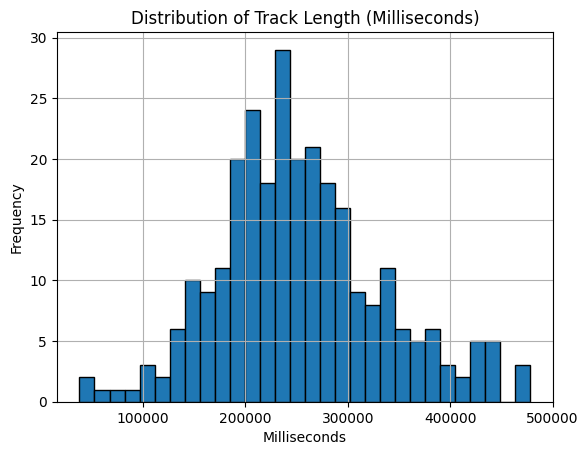

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Loading & Inspecting Data[cite: 7]
df = pd.read_csv('itunes_data.csv')
print(df.info())
print(df.describe())

# 2. Missing Value Imputation & Deduplication[cite: 7]
df['Composer'] = df['Composer'].fillna('Unknown')
df.drop_duplicates(inplace=True)

# 3. IQR Outlier Filtering (.copy() prevents SettingWithCopyWarning)[cite: 7]
q1 = df['Milliseconds'].quantile(0.25)
q3 = df['Milliseconds'].quantile(0.75)
iqr = q3 - q1
df_clean = df[(df['Milliseconds'] >= q1 - 1.5 * iqr) & (df['Milliseconds'] <= q3 + 1.5 * iqr)].copy()

# 4. Feature Transformations & Grouping[cite: 7]
df_clean['Seconds'] = df_clean['Milliseconds'] / 1000
genre_summary = df_clean.groupby('Genre')['Seconds'].mean().sort_values(ascending=False)
print("\nAverage Track Length by Genre (Seconds):")
print(genre_summary.head())

# 5. Quick EDA Plotting[cite: 7]
df_clean['Milliseconds'].hist(bins=30, edgecolor='black')
plt.title('Distribution of Track Length (Milliseconds)')
plt.xlabel('Milliseconds')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
import os
from google.colab import userdata

# Grab the GitHub token securely from Colab Secrets
gh_token = userdata.get('COS580-O')
repo_url = f"https://{gh_token}@github.com/michaeldavid90069-AiEngineer/COS580-michaeldavid90069-AiEngineer.git"

# Re-build the README file for the new repo
readme_text = """# COS580-O Machine Learning: Data Science Review

## Project Overview
This repository contains the foundational data preparation and exploratory data analysis (EDA) pipeline for COS580-O. This pipeline handles missing value imputation, deduplication, and Interquartile Range (IQR) outlier filtering on the raw iTunes dataset.

## Technical Stack
* **Language:** Python
* **Libraries:** Pandas, Matplotlib
* **Environment:** Google Colab
"""

with open("README.md", "w") as file:
    file.write(readme_text)

# Clean up any previous git tracking, configure Git, and push
os.system('rm -rf .git')
os.system('git config --global user.name "Michael David"')
os.system('git config --global user.email "michaeldavid@student.fullsail.edu"') # Swap in your actual student email
os.system('git init')
os.system('git branch -M main')
os.system('git add README.md itunes_data.csv')
os.system('git commit -m "Initialize COS580 repository with README and dataset"')
os.system(f'git push -u {repo_url} main --force')

print("Successfully pushed the data and README to the new COS580 repository.")

Successfully pushed the data and README to the new COS580 repository.
